In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# --- Cell 1: get the latest code, check the annotation file exists ---
import os, subprocess, sys
from pathlib import Path

REPO_URL = "https://github.com/SagarInspires/crowd-intelligence.git"
REPO_DIR = "/kaggle/working/crowd-intelligence"

def sync_repo():
    """Clone the repo on a fresh session, or pull the newest code if it is already
    there, then make the `src` folder importable."""
    if os.path.isdir(REPO_DIR):
        subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
    else:
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)

def require(path):
    """Return the path if the file exists; otherwise stop and say what is missing."""
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p}. Did you commit and push it from your laptop?")
    return p

sync_repo()
ann = require(f"{REPO_DIR}/data/your_video/annotations/via_project_phase0.json")
print("Found annotation file:", ann, f"({ann.stat().st_size // 1024} KB)")

Cloning into '/kaggle/working/crowd-intelligence'...


Found annotation file: /kaggle/working/crowd-intelligence/data/your_video/annotations/via_project_phase0.json (535 KB)


### Step 1 — Get the latest code and the annotation file
Every notebook starts by downloading the newest version of the project code from
GitHub, so notebooks stay short and the code stays in one place. Then it checks
that the file with my hand-marked heads is really there before doing anything else.

In [2]:
# --- Cell 2: turn the VIA annotations into clean CSV files ---
import json, math
from pathlib import Path
import pandas as pd

ANN_JSON = Path(REPO_DIR) / "data/your_video/annotations/via_project_phase0.json"
OUT_DIR = Path(REPO_DIR) / "data/your_video"
W, H = 1080, 1920          # frame size (width, height) from camera_config.json

def load_via_project(path):
    """Read a VIA project .json and return {image filename: list of shape dicts}
    (each shape dict is a point, rect or polygon exactly as VIA stored it)."""
    with open(path) as f:
        d = json.load(f)
    return {v["filename"]: [r["shape_attributes"] for r in v["regions"]]
            for v in d["_via_img_metadata"].values()}

def frame_id_from_name(name):
    """'frame_00279.jpg' -> 279 (the frame number inside the video)."""
    return int(Path(name).stem.split("_")[1])

def merge_close_points(points, min_dist=6.0):
    """Treat two points closer than min_dist pixels as one accidental double-click:
    keep the first, drop the later one. Returns (kept points, number dropped)."""
    kept = []
    for p in points:
        if all(math.hypot(p[0] - q[0], p[1] - q[1]) >= min_dist for q in kept):
            kept.append(p)
    return kept, len(points) - len(kept)

def to_vertices(shape):
    """Return an ignore region as a list of [x, y] corners (rectangles become 4 corners),
    or None if the shape is not an ignore region."""
    if shape["name"] == "polygon":
        return [[x, y] for x, y in zip(shape["all_points_x"], shape["all_points_y"])]
    if shape["name"] == "rect":
        x, y, w, h = shape["x"], shape["y"], shape["width"], shape["height"]
        return [[x, y], [x + w, y], [x + w, y + h], [x, y + h]]
    return None

def polygon_area(verts):
    """Area in pixels of a polygon given as [[x, y], ...] (shoelace formula)."""
    n = len(verts)
    s = sum(verts[i][0] * verts[(i + 1) % n][1] - verts[(i + 1) % n][0] * verts[i][1]
            for i in range(n))
    return abs(s) / 2

shapes = load_via_project(ANN_JSON)
point_rows, ignore_rows, summary = [], [], []
for fname in sorted(shapes):
    fid = frame_id_from_name(fname)
    raw_pts = [(s["cx"], s["cy"]) for s in shapes[fname] if s["name"] == "point"]
    pts, dropped = merge_close_points(raw_pts)
    point_rows += [{"frame_id": fid, "x": x, "y": y, "annotator": "sagar"} for x, y in pts]
    ignore_area = 0.0
    region_id = 0
    for s in shapes[fname]:
        verts = to_vertices(s)
        if verts is None:
            continue
        ignore_rows.append({"frame_id": fid, "region_id": region_id,
                            "vertices": json.dumps(verts)})
        ignore_area += polygon_area(verts)
        region_id += 1
    summary.append({"frame_id": fid, "n_points": len(pts), "dup_dropped": dropped,
                    "n_ignore_regions": region_id,
                    "ignore_pct_of_frame": round(100 * ignore_area / (W * H), 1)})

pd.DataFrame(point_rows).to_csv(OUT_DIR / "head_points.csv", index=False)
pd.DataFrame(ignore_rows).to_csv(OUT_DIR / "ignore_regions.csv", index=False)
summary = pd.DataFrame(summary)
print(summary.to_string(index=False))
print("\nTrue count per frame: mean %.1f | std %.1f | min %d | max %d"
      % (summary.n_points.mean(), summary.n_points.std(), summary.n_points.min(),
         summary.n_points.max()))
print("Double-click points dropped:", int(summary.dup_dropped.sum()),
      "of", int(summary.n_points.sum() + summary.dup_dropped.sum()))
print("Saved:", OUT_DIR / "head_points.csv", "and", OUT_DIR / "ignore_regions.csv")

 frame_id  n_points  dup_dropped  n_ignore_regions  ignore_pct_of_frame
        0       535            0                 1                  7.4
       93       440            0                 1                  9.8
      186       502            1                 1                  8.7
      279       454            0                 1                  8.7
      372       438            0                 1                  8.7
      465       401            0                 1                  9.6
      558       488            0                 1                  5.9
      651       443            4                 1                  8.9
      744       411            2                 1                  8.0
      837       449            0                 1                  6.9
      930       441            0                 1                  5.6
     1023       451            1                 3                  6.7
     1116       433            1                 1              

### Step 2 — Turn my clicks into clean tables
The annotation tool saves everything in one messy file. This step reads it and
writes two simple tables: `head_points.csv` (one row per head I marked) and
`ignore_regions.csv` (the far-away areas where heads blur together and can't be
counted). It also removes accidental double-clicks (two points less than 6 pixels
apart), then prints the true head count for each of the 15 frames. These counts,
marked by a human, are the reference every model gets compared against.

In [3]:
import json, time
from dataclasses import dataclass
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

@dataclass(frozen=True)
class GTConfig:
    """All ground-truth generation settings in one place, so every run is reproducible and loggable."""
    data: Path
    out: Path
    sigma_fixed: float = 15.0        # fixed-kernel std in px (ShanghaiTech-B convention)
    beta: float = 0.3                # geometry-adaptive: sigma_i = beta * mean kNN distance (Zhang et al., CVPR 2016)
    k: int = 3                       # number of neighbours used for the adaptive kernel
    sigma_min: float = 2.0           # clip range for adaptive sigma, in px
    sigma_max: float = 25.0
    stride: int = 8                  # model output stride (CSRNet / DM-Count use 1/8)
    tol: float = 1e-3                # mass-conservation tolerance in heads

CFG = GTConfig(data=Path(f"{REPO_DIR}/data/your_video"), out=Path("/kaggle/working/outputs/gt"))
CFG.out.mkdir(parents=True, exist_ok=True)

def frame_size(frames_dir, fids):
    """Read the true (H, W) from the JPEGs and assert that all frames share it."""
    shapes = {cv2.imread(str(frames_dir / f"frame_{f:05d}.jpg")).shape[:2] for f in fids}
    assert len(shapes) == 1, f"frames differ in size: {shapes}"
    return shapes.pop()

def _axis_kernel(c, sigma, n):
    """1-D Gaussian around c over [0, n), truncated at 4 sigma and re-normalised to sum 1.
    Renormalising each axis makes the 2-D blob sum to exactly 1 even at image borders."""
    r = int(np.ceil(4 * sigma))
    lo, hi = max(int(np.floor(c)) - r, 0), min(int(np.floor(c)) + r + 1, n)
    g = np.exp(-0.5 * ((np.arange(lo, hi) - c) / sigma) ** 2)
    return lo, hi, g / g.sum()

def render_density(xy, sigmas, shape):
    """Sum of unit-mass Gaussian blobs, one per head, each with its own sigma (float64 accumulate)."""
    H, W = shape
    d = np.zeros(shape, np.float64)
    for (x, y), s in zip(xy, sigmas):
        x0, x1, gx = _axis_kernel(x, s, W)
        y0, y1, gy = _axis_kernel(y, s, H)
        d[y0:y1, x0:x1] += np.outer(gy, gx)
    return d

def adaptive_sigmas(xy, cfg):
    """sigma_i = beta * mean distance to the k nearest neighbours: small in dense crowd, large when isolated."""
    if len(xy) <= cfg.k:
        return np.full(len(xy), cfg.sigma_fixed)
    dist, _ = cKDTree(xy).query(xy, k=cfg.k + 1)      # column 0 = the point itself
    return np.clip(cfg.beta * dist[:, 1:].mean(1), cfg.sigma_min, cfg.sigma_max)

def valid_mask(polys, shape):
    """1 = counted, 0 = ignore region. Kept SEPARATE from the density: apply it in the loss and in every metric."""
    m = np.ones(shape, np.uint8)
    for v in polys:
        cv2.fillPoly(m, [np.round(np.asarray(v)).astype(np.int32)], 0)
    return m

def heads_in_ignore(xy, polys):
    """Exact geometric test (not the pixel mask): number of heads strictly inside any ignore polygon."""
    n = 0
    for x, y in xy:
        n += any(cv2.pointPolygonTest(np.asarray(v, np.float32).reshape(-1, 1, 2), (float(x), float(y)), False) > 0
                 for v in polys)
    return n

def sum_pool(a, s):
    """Mass-preserving downsample (sum over s x s blocks); the correct way to get 1/8-resolution targets."""
    H, W = a.shape
    assert H % s == 0 and W % s == 0, f"{a.shape} not divisible by stride {s}"
    return a.reshape(H // s, s, W // s, s).sum((1, 3))

def peak_window_count(d, win=64):
    """Largest number of heads inside any win x win px window: a crowding indicator and a rough rho_max."""
    ii = np.pad(d.cumsum(0).cumsum(1), ((1, 0), (1, 0)))
    box = ii[win:, win:] - ii[:-win, win:] - ii[win:, :-win] + ii[:-win, :-win]
    return box.max()

def build_frame(fid, g, polys, shape, cfg):
    """Everything for one frame: fixed + adaptive density, mask, 1/8 targets, and hard sanity checks."""
    xy = g[["x", "y"]].to_numpy(float)
    H, W = shape
    hi = np.array([W - 1, H - 1], float)
    assert ((xy >= -2) & (xy <= hi + 2)).all(), f"frame {fid}: points more than 2 px outside the image"
    n_clipped = int((((xy < 0) | (xy > hi)).any(1)).sum())   # heads on the border that VIA put 1 px outside
    xy = np.clip(xy, 0, hi)                                   # valid pixel indices are 0..W-1 and 0..H-1
    m = valid_mask(polys, shape)
    assert heads_in_ignore(xy, polys) == 0, f"frame {fid}: a head lies inside an ignore region"
    sig = adaptive_sigmas(xy, cfg)
    out, row = {}, dict(frame_id=fid, n_heads=len(xy), n_clipped=n_clipped, ignore_pct=100 * (1 - m.mean()),
                        sigma_med=np.median(sig), sigma_p5=np.percentile(sig, 5), sigma_p95=np.percentile(sig, 95))
    for name, s in (("fixed", np.full(len(xy), cfg.sigma_fixed)), ("adaptive", sig)):
        d = render_density(xy, s, shape)
        d8 = sum_pool(d, cfg.stride)
        assert abs(d.sum() - len(xy)) < cfg.tol, f"{fid}/{name}: mass {d.sum():.4f} != {len(xy)}"
        assert abs(d8.sum() - d.sum()) < cfg.tol, f"{fid}/{name}: pooling changed mass"
        row[f"leak_{name}_pct"] = 100 * d[m == 0].sum() / len(xy)      # blob mass bleeding into ignore area
        row[f"valid_sum_{name}"] = d[m == 1].sum()                     # what the loss/metric will actually see
        row[f"peak64_{name}"] = peak_window_count(d)
        out[name] = (d.astype(np.float32), d8.astype(np.float32))
    return out, m, row

pts = pd.read_csv(CFG.data / "head_points.csv")
ign = pd.read_csv(CFG.data / "ignore_regions.csv"); ign["vertices"] = ign["vertices"].apply(json.loads)
SHAPE = frame_size(CFG.data / "annotated_frames", sorted(pts.frame_id.unique()))
print("frame size (H, W):", SHAPE)

rows, t0 = [], time.time()
for fid, g in pts.groupby("frame_id"):                # one frame at a time
    out, m, row = build_frame(fid, g, ign[ign.frame_id == fid]["vertices"].tolist(), SHAPE, CFG)
    np.savez_compressed(CFG.out / f"frame_{fid:05d}.npz", mask=m,
                        mask8=sum_pool(m.astype(np.float32), CFG.stride) / CFG.stride**2,
                        fixed=out["fixed"][0], adaptive=out["adaptive"][0],
                        fixed8=out["fixed"][1], adaptive8=out["adaptive"][1])
    rows.append(row)
res = pd.DataFrame(rows); res.to_csv(CFG.out / "gt_summary.csv", index=False)
print(f"built {len(res)} frames in {time.time() - t0:.1f}s; all mass-conservation and mask assertions passed")
print(res.round(2).to_string(index=False))

frame size (H, W): (1920, 1080)
built 15 frames in 14.3s; all mass-conservation and mask assertions passed
 frame_id  n_heads  n_clipped  ignore_pct  sigma_med  sigma_p5  sigma_p95  leak_fixed_pct  valid_sum_fixed  peak64_fixed  leak_adaptive_pct  valid_sum_adaptive  peak64_adaptive
        0      535          0        7.48       9.34      5.36      21.86            0.07           534.60          8.93               0.01              534.96             9.78
       93      440          1        9.82      10.93      6.53      23.10            0.56           437.53          7.31               0.31              438.64             8.75
      186      502          0        8.70       9.64      5.16      21.57            0.76           498.17         12.41               0.22              500.89            13.89
      279      454          0        8.78       9.69      5.38      21.95            0.88           450.02         10.65               0.30              452.62            12.82
      37

## Step 3: Build the ground truth for the model (density maps)

**In simple words:** the model cannot learn from dots. So each head dot becomes a small soft blob that adds up to exactly 1 person. Adding up the whole picture gives the head count. We build two versions to compare later: a fixed blob size, and an adaptive one (small blobs in tight crowds, big blobs for isolated heads).

**Why it is trustworthy:** the code stops with an error if any frame's total differs from our head count by more than 0.001, if a head lies inside an ignore region, or if a dot falls outside the image.

**Ignore regions:** kept as a separate mask. The model is never punished for what it predicts there, and those areas are excluded from every score.

**Outputs:** one file per frame (full-size maps, 1/8-size training maps, and the mask) plus a summary table. Nothing is committed to git because the files are large.

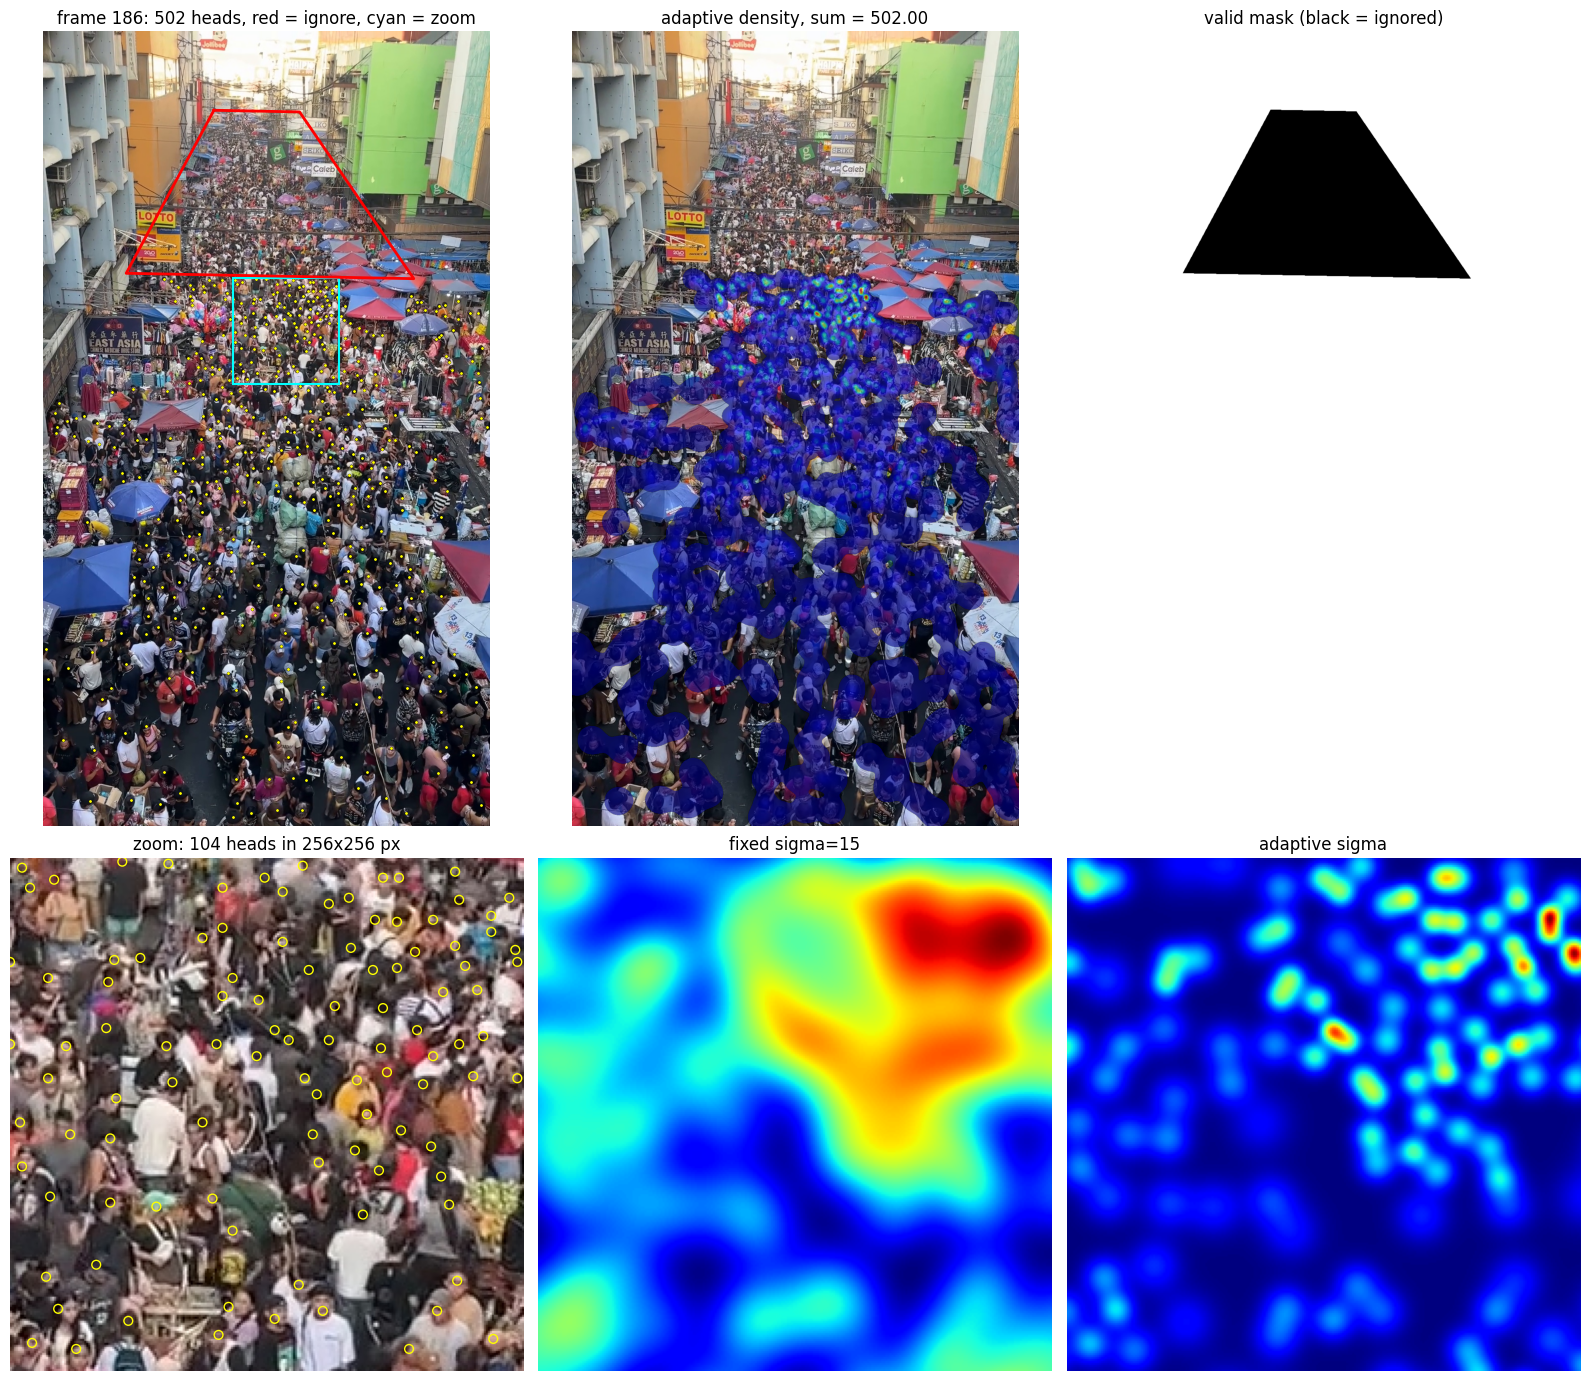

In [4]:
import matplotlib.pyplot as plt

def densest_window(d, win=256):
    """Top-left corner (x, y) of the win x win window holding the most density; used for the zoom panel."""
    ii = np.pad(d.cumsum(0).cumsum(1), ((1, 0), (1, 0)))
    box = ii[win:, win:] - ii[:-win, win:] - ii[win:, :-win] + ii[:-win, :-win]
    y, x = np.unravel_index(box.argmax(), box.shape)
    return x, y

def show_frame(fid, cfg=CFG, pts=pts, ign=ign, win=256):
    """Row 1: frame + dots + ignore polygon | adaptive density overlay | mask.  Row 2: zoom on the densest 256 px window
    with dots, so alignment of dots to heads can be judged at pixel level."""
    img = cv2.cvtColor(cv2.imread(str(cfg.data / "annotated_frames" / f"frame_{fid:05d}.jpg")), cv2.COLOR_BGR2RGB)
    z = np.load(cfg.out / f"frame_{fid:05d}.npz")
    g = pts[pts.frame_id == fid]
    polys = ign[ign.frame_id == fid]["vertices"].tolist()
    x0, y0 = densest_window(z["adaptive"], win)
    fig, ax = plt.subplots(2, 3, figsize=(16, 14), gridspec_kw=dict(height_ratios=[3, 2]))
    ax[0, 0].imshow(img)
    ax[0, 0].scatter(g.x, g.y, s=5, c="yellow", edgecolors="k", linewidths=0.2)
    for v in polys:
        v = np.array(v + [v[0]]); ax[0, 0].plot(v[:, 0], v[:, 1], "r-", lw=2)
    ax[0, 0].add_patch(plt.Rectangle((x0, y0), win, win, fill=False, ec="cyan", lw=1.5))
    ax[0, 0].set_title(f"frame {fid}: {len(g)} heads, red = ignore, cyan = zoom")
    ax[0, 1].imshow(img); ax[0, 1].imshow(np.ma.masked_less(z["adaptive"], 1e-4), cmap="jet", alpha=0.6)
    ax[0, 1].set_title(f"adaptive density, sum = {z['adaptive'].sum():.2f}")
    ax[0, 2].imshow(z["mask"], cmap="gray", vmin=0, vmax=1); ax[0, 2].set_title("valid mask (black = ignored)")
    sl = (slice(y0, y0 + win), slice(x0, x0 + win))
    inwin = g[(g.x >= x0) & (g.x < x0 + win) & (g.y >= y0) & (g.y < y0 + win)]
    ax[1, 0].imshow(img[sl], extent=(x0, x0 + win, y0 + win, y0))
    ax[1, 0].scatter(inwin.x, inwin.y, s=40, facecolors="none", edgecolors="yellow", linewidths=1)
    ax[1, 0].set_title(f"zoom: {len(inwin)} heads in {win}x{win} px")
    ax[1, 1].imshow(z["fixed"][sl], cmap="jet", extent=(x0, x0 + win, y0 + win, y0)); ax[1, 1].set_title("fixed sigma=15")
    ax[1, 2].imshow(z["adaptive"][sl], cmap="jet", extent=(x0, x0 + win, y0 + win, y0)); ax[1, 2].set_title("adaptive sigma")
    for a in ax.ravel():
        a.axis("off")
    plt.tight_layout(); plt.show()

show_frame(186)     # change to any of your 15 frame ids to inspect others

## Step 4: Visual check of the ground truth

**In simple words:** numbers can pass and the labels can still be wrong, for example if dots are shifted. Top row: the frame with our yellow dots and the red ignore region, the density heat map laid on the frame, and the ignore mask. Bottom row: the busiest small patch zoomed in, so we can check at pixel level that each dot sits on a head and each blob is the right size. The two heat maps show the fixed blob size and the adaptive blob size side by side.